In [2]:
from recommender_system.data.load import load_data
from recommender_system.data.transform import transform_reviews

df = load_data('../data/australian_user_reviews.json.gz')
reviews = transform_reviews(df)

reviews.info()
reviews.head()

<class 'pandas.DataFrame'>
Index: 59305 entries, 0 to 59332
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_id    59305 non-null  str  
 1   posted     59305 non-null  str  
 2   item_id    59305 non-null  str  
 3   recommend  59305 non-null  bool 
dtypes: bool(1), str(3)
memory usage: 1.9 MB


,user_id,posted,item_id,recommend
0,76561197970982479,"Posted November 5, 2011.",1250,True
1,76561197970982479,"Posted July 15, 2011.",22200,True
2,76561197970982479,"Posted April 21, 2011.",43110,True
3,js41637,"Posted June 24, 2014.",251610,True
4,js41637,"Posted September 8, 2013.",227300,True


user_id       str
posted        str
item_id       str
recommend    bool
dtype: object


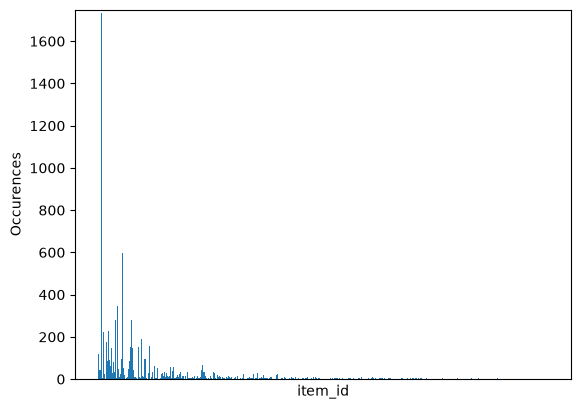

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

column = 'item_id'
print(reviews.dtypes)
plt.hist(reviews[column], bins=len(reviews[column].unique()))
frame = plt.gca()
frame.axes.xaxis.set_ticks([])
plt.xlabel(column)
plt.ylabel('Occurences')
plt.ylim(0, 1750)
plt.show()

In [13]:
reviews.describe()

,user_id,posted,item_id,recommend
count,59305,59305,59305,59305
unique,25458,1906,3682,2
top,chicken_tonight,"Posted June 21, 2014.",730,True
freq,20,225,3759,52473


In [7]:
#print(reviews[column].value_counts())

num_positive = reviews.groupby('item_id')['recommend'].sum()
num_negative = reviews.groupby('item_id')['recommend'].count() - num_positive
#num_positive = num_positive.sort_values(by='recommend', ascending=False)
#print(num_positive)
reviews_per_game = pd.DataFrame(reviews['item_id'].unique(), columns=['item_id'])
reviews_per_game = reviews_per_game.join(pd.DataFrame([num_positive, num_negative]).T, on='item_id')
reviews_per_game.columns = ['item_id', 'num_positive', 'num_negative']

In [3]:
games = load_data("../data/steam_games.json.gz")
games = games.rename({'id': 'item_id'}, axis=1)
games.head()

,publisher,genres,app_name,title,url,release_date,tags,discount_price,reviews_url,specs,price,early_access,item_id,developer,sentiment,metascore
0,Kotoshiro,"[Action, Casual, Indie, Simulation, Strategy]",Lost Summoner Kitty,Lost Summoner Kitty,http://store.steampowered.com/app/761140/Lost_...,2018-01-04,"[Strategy, Action, Indie, Casual, Simulation]",4.49,http://steamcommunity.com/app/761140/reviews/?...,[Single-player],4.99,False,761140,Kotoshiro,NaN,NaN
1,"Making Fun, Inc.","[Free to Play, Indie, RPG, Strategy]",Ironbound,Ironbound,http://store.steampowered.com/app/643980/Ironb...,2018-01-04,"[Free to Play, Strategy, Indie, RPG, Card Game...",NaN,http://steamcommunity.com/app/643980/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free To Play,False,643980,Secret Level SRL,Mostly Positive,NaN
2,Poolians.com,"[Casual, Free to Play, Indie, Simulation, Sports]",Real Pool 3D - Poolians,Real Pool 3D - Poolians,http://store.steampowered.com/app/670290/Real_...,2017-07-24,"[Free to Play, Simulation, Sports, Casual, Ind...",NaN,http://steamcommunity.com/app/670290/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free to Play,False,670290,Poolians.com,Mostly Positive,NaN
3,彼岸领域,"[Action, Adventure, Casual]",弹炸人2222,弹炸人2222,http://store.steampowered.com/app/767400/2222/,2017-12-07,"[Action, Adventure, Casual]",0.83,http://steamcommunity.com/app/767400/reviews/?...,[Single-player],0.99,False,767400,彼岸领域,NaN,NaN
4,NaN,NaN,Log Challenge,NaN,http://store.steampowered.com/app/773570/Log_C...,NaN,"[Action, Indie, Casual, Sports]",1.79,http://steamcommunity.com/app/773570/reviews/?...,"[Single-player, Full controller support, HTC V...",2.99,False,773570,NaN,NaN,NaN


In [9]:
reviews_per_game = pd.merge(games[['app_name', 'item_id']], reviews_per_game, on='item_id')
reviews_per_game = reviews_per_game.sort_values(by='num_positive', ascending=False, ignore_index=True)
reviews_per_game.head(n=20)

,app_name_x,item_id,app_name_y,num_positive,num_negative
0,Team Fortress 2,440,Team Fortress 2,3611,125
1,Counter-Strike: Global Offensive,730,Counter-Strike: Global Offensive,3478,281
2,Garry's Mod,4000,Garry's Mod,1685,50
3,Dota 2,570,Dota 2,1458,104
4,Unturned,304930,Unturned,961,89
5,PAYDAY 2,218620,PAYDAY 2,910,227
6,Left 4 Dead 2,550,Left 4 Dead 2,731,21
7,Terraria,105600,Terraria,723,18
8,Rust,252490,Rust,702,113
9,DayZ,221100,DayZ,575,162
